# Check Imports and Directory Location

In [174]:
import os
import pandas as pd
import numpy as np

os.chdir(r"D:\Workplace\ECMWF Code for Earth Challenge\Coding Phase\TriHydrA")

print("Current working directory:")
print(os.getcwd())

Current working directory:
D:\Workplace\ECMWF Code for Earth Challenge\Coding Phase\TriHydrA


In [175]:
from src.trihydra.layer1.checks import (
    check_missing_values,
    check_long_gaps,
    check_negative_discharge,
    check_duplicate_timestamps,
    check_timestep_consistency,
    check_low_variability_flow,
    check_zero_flow_regime,
    check_single_point_spike_dip) 

''',
    check_step_shift,
    check_gradual_drift,
)'''

print("Imports successful.")

Imports successful.


# GRDC_6341500

## Functions

In [178]:
# Some EDA

pd.set_option("display.float_format", "{:.4f}".format)

def summarize_series(series, series_name):
    s = series.dropna()

    return {
        "series": series_name,
        "start_date": series.index.min(),
        "end_date": series.index.max(),
        "total_count": len(series),
        "min": float(s.min()) if len(s) > 0 else np.nan,
        "q05": float(s.quantile(0.05)) if len(s) > 0 else np.nan,
        "median": float(s.median()) if len(s) > 0 else np.nan,
        "mean": float(s.mean()) if len(s) > 0 else np.nan,
        "q95": float(s.quantile(0.95)) if len(s) > 0 else np.nan,
        "max": float(s.max()) if len(s) > 0 else np.nan,
    }

# Call Layer 1 Checks

def run_layer1_checks(series, series_name):
    results = [
        check_missing_values(series),
        check_long_gaps(series),
        check_negative_discharge(series),
        check_duplicate_timestamps(series),
        check_timestep_consistency(series),
        check_low_variability_flow(series),
        check_zero_flow_regime(series),
        check_single_point_spike_dip(series)
    ]

    ''',
        check_step_shift(series),
        check_gradual_drift(series),'''
    
    results_df = pd.DataFrame(results)
    results_df.insert(0, "series", series_name)

    return results_df

## Load Basin Data:

In [180]:
# station_id = "GRDC_6341500"
# station_id = "GRDC_4123300"
station_id = "GRDC_5304140"

data_folder = r"D:\Workplace\ECMWF Code for Earth Challenge\Coding Phase\TriHydrA\data"
file_path = f"{data_folder}\\{station_id}_streamflow_data.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:")
print(df.columns)

display(df.head())

Shape: (16063, 8)
Columns:
Index(['Date', 'Station_ID', 'Basin_role', 'Area_km2', 'Observed_mm_day',
       'Simulated_mm_day', 'Observed_m3s', 'Simulated_m3s'],
      dtype='str')


,Date,Station_ID,Basin_role,Area_km2,Observed_mm_day,Simulated_mm_day,Observed_m3s,Simulated_m3s
0,1980-01-10,GRDC_5304140,Regulated dry/semi-arid case,113128.1000,0.0200,0.0792,26.1870,103.6363
1,1980-01-11,GRDC_5304140,Regulated dry/semi-arid case,113128.1000,0.0200,0.0801,26.1870,104.8379
2,1980-01-12,GRDC_5304140,Regulated dry/semi-arid case,113128.1000,0.0200,0.0804,26.1870,105.3264
3,1980-01-13,GRDC_5304140,Regulated dry/semi-arid case,113128.1000,0.0200,0.0746,26.1870,97.6687
4,1980-01-14,GRDC_5304140,Regulated dry/semi-arid case,113128.1000,0.0200,0.0782,26.1870,102.3764


In [181]:
# Convert Date column to datetime and set as index
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

# Extract observed and simulated discharge in m3/s
obs = df["Observed_m3s"]
sim = df["Simulated_m3s"]

print("Prepared dataframe:")
print(df.index.min(), "to", df.index.max())
print("Observed length:", len(obs))
print("Simulated length:", len(sim))

display(df.head())

Prepared dataframe:
1980-01-10 00:00:00 to 2024-01-01 00:00:00
Observed length: 16063
Simulated length: 16063


,Station_ID,Basin_role,Area_km2,Observed_mm_day,Simulated_mm_day,Observed_m3s,Simulated_m3s
Date,,,,,,,
1980-01-10,GRDC_5304140,Regulated dry/semi-arid case,113128.1000,0.0200,0.0792,26.1870,103.6363
1980-01-11,GRDC_5304140,Regulated dry/semi-arid case,113128.1000,0.0200,0.0801,26.1870,104.8379
1980-01-12,GRDC_5304140,Regulated dry/semi-arid case,113128.1000,0.0200,0.0804,26.1870,105.3264
1980-01-13,GRDC_5304140,Regulated dry/semi-arid case,113128.1000,0.0200,0.0746,26.1870,97.6687
1980-01-14,GRDC_5304140,Regulated dry/semi-arid case,113128.1000,0.0200,0.0782,26.1870,102.3764


In [182]:
eda_df = pd.DataFrame([
    summarize_series(obs, "Observed_m3s"),
    summarize_series(sim, "Simulated_m3s"),
])

display(eda_df)

,series,start_date,end_date,total_count,min,q05,median,mean,q95,max
0,Observed_m3s,1980-01-10,2024-01-01,16063,13.0934,39.2807,91.6548,155.5157,523.7411,1924.7490
1,Simulated_m3s,1980-01-10,2024-01-01,16063,22.7647,52.5832,94.0615,143.3844,364.8956,2326.7400


### Run Checks on Observation Data

In [184]:
obs_layer1 = run_layer1_checks(obs, "Observed_m3s")
obs_flagged = obs_layer1[obs_layer1["flag"] == True]

display(obs_layer1)
display(obs_flagged)

,series,check,flag,value,threshold,flagged_timestamps,message,flagged_details
0,Observed_m3s,missing_values,True,0.0370,0.0500,"[1984-01-25 00:00:00, 1984-01-26 00:00:00, 198...",Missing count = 595; missing ratio = 3.70%; th...,NaN
1,Observed_m3s,long_gaps,True,106.0000,3,"[1984-01-25 00:00:00, 1984-01-26 00:00:00, 198...",Longest internal missing gap = 106 timestep(s).,NaN
2,Observed_m3s,negative_discharge,False,0.0000,-0.0000,[],Negative discharge count = 0,NaN
3,Observed_m3s,duplicate_timestamps,False,0.0000,0,[],Duplicate timestamp count = 0,NaN
4,Observed_m3s,timestep_consistency,False,1.0000,0.9500,[],Dominant timestep = 1 days 00:00:00; dominant ...,NaN
5,Observed_m3s,low_variability_flow,True,49.0000,CV < 0.005 for >= 7 timesteps,"[1980-02-10 00:00:00, 1980-02-11 00:00:00, 198...",Longest low-variability non-zero run = 49 time...,NaN
6,Observed_m3s,zero_flow_regime,False,0.0000,0.0000,[],No zero-flow values detected.,NaN
7,Observed_m3s,single_point_spike_dip,False,0.0000,spike >= 3.0x local reference; dip <= 0.333x l...,[],Single-point spike count = 0; single-point dip...,[]


,series,check,flag,value,threshold,flagged_timestamps,message,flagged_details
0,Observed_m3s,missing_values,True,0.0370,0.0500,"[1984-01-25 00:00:00, 1984-01-26 00:00:00, 198...",Missing count = 595; missing ratio = 3.70%; th...,NaN
1,Observed_m3s,long_gaps,True,106.0000,3,"[1984-01-25 00:00:00, 1984-01-26 00:00:00, 198...",Longest internal missing gap = 106 timestep(s).,NaN
5,Observed_m3s,low_variability_flow,True,49.0000,CV < 0.005 for >= 7 timesteps,"[1980-02-10 00:00:00, 1980-02-11 00:00:00, 198...",Longest low-variability non-zero run = 49 time...,NaN


In [185]:
spike_dip_result = obs_layer1[
    obs_layer1["check"] == "single_point_spike_dip"
].iloc[0]

spike_dip_details = pd.DataFrame(spike_dip_result["flagged_details"])

display(spike_dip_details)

""


### Run Checks on Simulated Data

In [187]:
sim_layer1 = run_layer1_checks(sim, "Simulated_m3s")
sim_flagged = sim_layer1[sim_layer1["flag"] == True]

display(sim_layer1)
display(sim_flagged)

,series,check,flag,value,threshold,flagged_timestamps,message,flagged_details
0,Simulated_m3s,missing_values,True,0.0141,0.0500,"[2023-05-20 00:00:00, 2023-05-21 00:00:00, 202...",Missing count = 227; missing ratio = 1.41%; th...,NaN
1,Simulated_m3s,long_gaps,False,0.0000,3,[],Longest internal missing gap = 0 timestep(s).,NaN
2,Simulated_m3s,negative_discharge,False,0.0000,-0.0000,[],Negative discharge count = 0,NaN
3,Simulated_m3s,duplicate_timestamps,False,0.0000,0,[],Duplicate timestamp count = 0,NaN
4,Simulated_m3s,timestep_consistency,False,1.0000,0.9500,[],Dominant timestep = 1 days 00:00:00; dominant ...,NaN
5,Simulated_m3s,low_variability_flow,False,1.0000,CV < 0.005 for >= 7 timesteps,[],Longest low-variability non-zero run = 1 times...,NaN
6,Simulated_m3s,zero_flow_regime,False,0.0000,0.0000,[],No zero-flow values detected.,NaN
7,Simulated_m3s,single_point_spike_dip,False,0.0000,spike >= 3.0x local reference; dip <= 0.333x l...,[],Single-point spike count = 0; single-point dip...,[]


,series,check,flag,value,threshold,flagged_timestamps,message,flagged_details
0,Simulated_m3s,missing_values,True,0.0141,0.0500,"[2023-05-20 00:00:00, 2023-05-21 00:00:00, 202...",Missing count = 227; missing ratio = 1.41%; th...,NaN


In [188]:
sim_spike_dip_result = sim_layer1[
    sim_layer1["check"] == "single_point_spike_dip"
].iloc[0]

sim_spike_dip_details = pd.DataFrame(sim_spike_dip_result["flagged_details"])

display(sim_spike_dip_details)

""


### Visualisation

In [190]:
import plotly.graph_objects as go

In [191]:
def get_flag_points(series, results_df):
    flag_rows = results_df[results_df["flag"] == True].copy()
    records = []

    for _, row in flag_rows.iterrows():
        check_name = row["check"]
        timestamps = row["flagged_timestamps"]

        if not isinstance(timestamps, list):
            continue

        for timestamp in timestamps:
            ts = pd.to_datetime(timestamp)

            if ts not in series.index:
                continue

            q_value = series.loc[ts]

            if isinstance(q_value, pd.Series):
                q_value = q_value.iloc[0]

            # Missing values have no y-value, so place marker at local median
            if pd.isna(q_value):
                local_window = series.loc[
                    ts - pd.Timedelta(days=7): ts + pd.Timedelta(days=7)
                ]
                q_value = local_window.median(skipna=True)

            records.append({
                "timestamp": ts,
                "q": q_value,
                "check": check_name,
                "message": row["message"],
                "threshold": row["threshold"],
            })

    return pd.DataFrame(records)

In [192]:
def plot_layer1_flags(series, results_df, title):
    flag_points = get_flag_points(series, results_df)

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=series.index,
            y=series.values,
            mode="lines",
            name="Discharge",
            line=dict(width=1),
            hovertemplate="Date: %{x}<br>Q: %{y:.4f}<extra></extra>",
        )
    )

    if not flag_points.empty:
        for check_name in flag_points["check"].unique():
            subset = flag_points[flag_points["check"] == check_name]

            fig.add_trace(
                go.Scatter(
                    x=subset["timestamp"],
                    y=subset["q"],
                    mode="markers",
                    name=check_name,
                    marker=dict(size=8),
                    customdata=subset[["message", "threshold"]],
                    hovertemplate=(
                        "Date: %{x}<br>"
                        "Q: %{y:.4f}<br>"
                        "Message: %{customdata[0]}<br>"
                        "Threshold: %{customdata[1]}"
                        "<extra></extra>"
                    ),
                )
            )

    fig.update_layout(
        title=title,
        xaxis_title="Date",
        yaxis_title="Discharge (m³/s)",
        hovermode="closest",
        height=600,
        xaxis=dict(
            rangeslider=dict(visible=True),
            type="date"
        ),
        legend_title="Layer 1 flags",
    )

    fig.show()

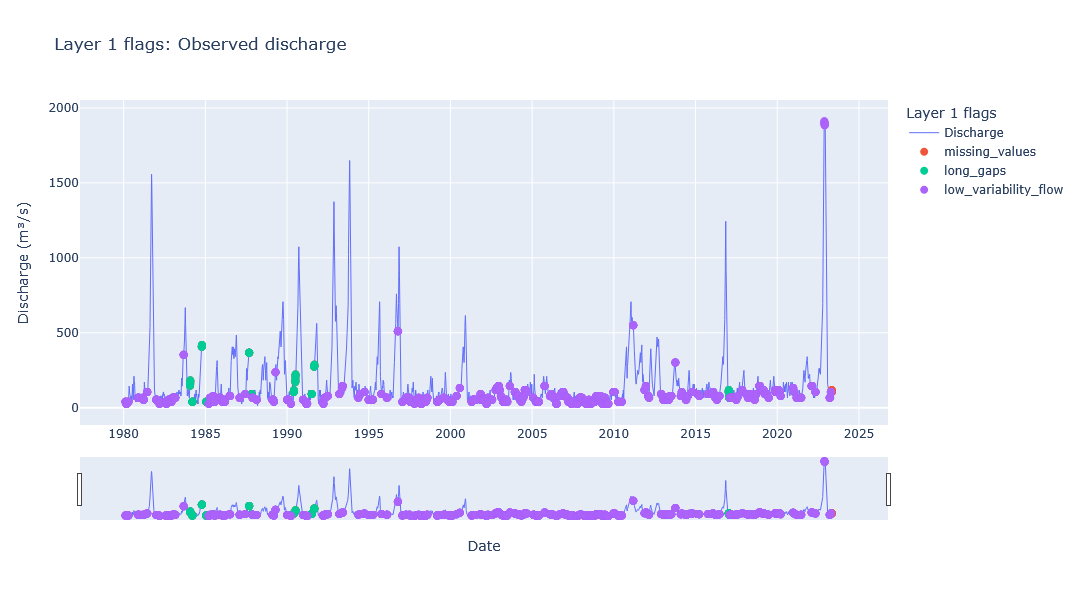

In [193]:
plot_layer1_flags(
    obs,
    obs_layer1,
    "Layer 1 flags: Observed discharge"
)

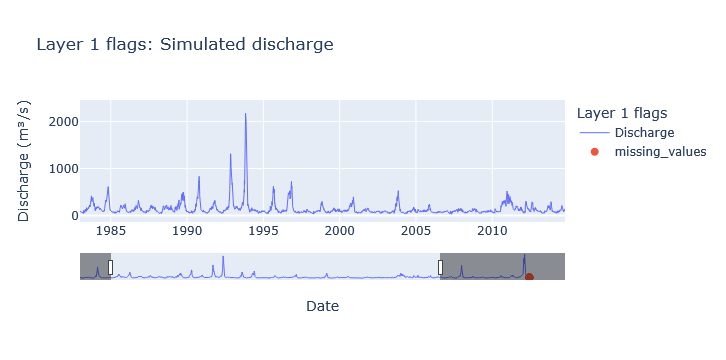

In [194]:
plot_layer1_flags(
    sim,
    sim_layer1,
    "Layer 1 flags: Simulated discharge"
)